# Module 7 — Unsupervised Learning
## In-Class Practice: Clustering & PCA

**Goal:** Practice applying K-Means, DBSCAN, Hierarchical Clustering, PCA, and
cluster evaluation metrics on **two different datasets**.

By the end of this activity, you should be able to:
- Run K-Means and Hierarchical Clustering on numeric data.
- Run DBSCAN on a non-convex dataset and compare with K-Means.
- Use PCA as a preprocessing / visualization step.
- Evaluate cluster quality with **silhouette**, **Davies–Bouldin**, and
  **Calinski–Harabasz** indices.

👉 Work through the steps in order and fill in all cells marked `# TODO`.
Do **not** modify the dataset generation cells so that everyone works with
the same data.

In [5]:
# Step 0 — Imports (you may add more if needed)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Display utilities
from IPython.display import Markdown, display

# Reproducibility
random_state = 42

plt.rcParams['figure.figsize'] = (6, 5)
%matplotlib inline

---
## Part A — Dataset 1: Numeric Blobs (Good for K-Means / Hierarchical)

We start with a synthetic **5-dimensional** dataset with 4 Gaussian-like
clusters. This is similar to the kind of data where **K-Means** and
**Agglomerative (Ward) Hierarchical Clustering** tend to work well.

In [7]:
# DO NOT MODIFY THIS CELL
# Dataset 1: 5D numeric blobs with 4 underlying clusters
X1, y1_true = make_blobs(
    n_samples=500,
    centers=4,
    n_features=5,
    cluster_std=[1.0, 1.4, 1.2, 0.8],
    random_state=42
)

df1 = pd.DataFrame(X1, columns=[f'feat_{i}' for i in range(X1.shape[1])])
df1['true_label'] = y1_true
df1.head()

,feat_0,feat_1,feat_2,feat_3,feat_4,true_label
0,-10.868069,-7.230056,4.887924,1.514883,2.593914,1
1,-9.732768,6.790994,7.665759,-6.395612,-6.472141,2
2,-8.485418,9.049868,6.969724,-5.367180,-7.165209,2
3,-7.461608,11.391708,6.100337,-6.475872,-5.800972,2
4,-3.348415,8.705074,4.971142,2.948715,-7.358801,0


### A.1 — Quick Exploration & Visualization
1. Print the shape of `df1` and basic `.describe()` for the feature columns.
2. Make a scatter plot of **two chosen features** (e.g., `feat_0` vs `feat_1`).
3. Make a second scatter coloured by `true_label` (just for intuition —
   **do not** use `true_label` during clustering itself).

Shape: (500, 6)

Head:


,feat_0,feat_1,feat_2,feat_3,feat_4,true_label
0,-10.868069,-7.230056,4.887924,1.514883,2.593914,1
1,-9.732768,6.790994,7.665759,-6.395612,-6.472141,2
2,-8.485418,9.049868,6.969724,-5.367180,-7.165209,2
3,-7.461608,11.391708,6.100337,-6.475872,-5.800972,2
4,-3.348415,8.705074,4.971142,2.948715,-7.358801,0



Describe:


,feat_0,feat_1,feat_2,feat_3,feat_4,true_label
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,-6.331576,1.455673,4.795240,-0.658470,-3.265579,1.500000
std,2.784447,8.046221,2.911406,3.397327,4.638623,1.119154
min,-13.093931,-12.231759,-1.588242,-9.199932,-9.607379,0.000000
25%,-8.350976,-5.423490,2.620542,-3.224257,-6.610550,0.750000
50%,-6.562101,2.184031,5.354549,-0.081998,-4.942355,1.500000
75%,-4.373184,9.172792,7.018595,2.044277,-1.100041,2.250000
max,-0.433797,11.986967,10.935116,5.825901,7.846786,3.000000


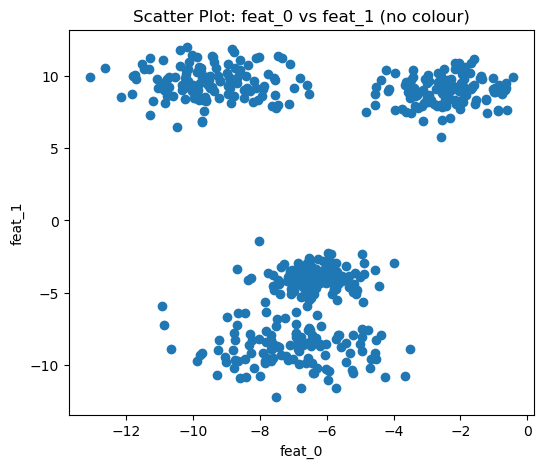

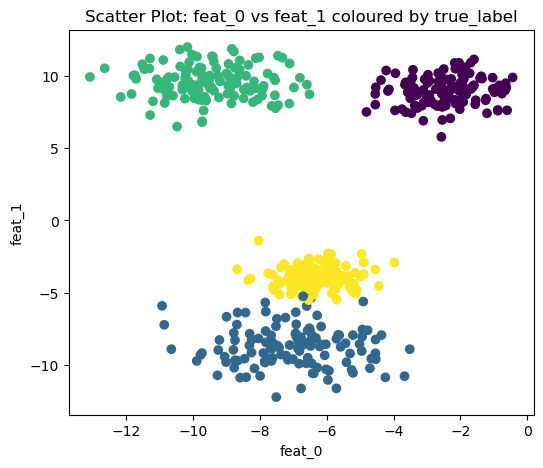

In [9]:
# TODO A.1
# 1) Inspect df1 (shape, head, describe).
# 2) Scatter feat_0 vs feat_1 (no colour).
# 3) Scatter feat_0 vs feat_1 coloured by true_label.

# ✅ 1) Inspect df1 (shape, head, describe)
print("Shape:", df1.shape)
print("\nHead:")
display(df1.head())
print("\nDescribe:")
display(df1.describe())

# ✅ 2) Scatter feat_0 vs feat_1 (no colour)
plt.figure()
plt.scatter(df1["feat_0"], df1["feat_1"])
plt.xlabel("feat_0")
plt.ylabel("feat_1")
plt.title("Scatter Plot: feat_0 vs feat_1 (no colour)")
plt.show()

# ✅ 3) Scatter feat_0 vs feat_1 coloured by true_label
plt.figure()
plt.scatter(df1["feat_0"], df1["feat_1"], c=df1["true_label"])
plt.xlabel("feat_0")
plt.ylabel("feat_1")
plt.title("Scatter Plot: feat_0 vs feat_1 coloured by true_label")
plt.show()


### A.2 — Standardize Features
Most distance-based clustering methods assume features are on comparable
scales.

1. Select only the feature columns (no `true_label`).
2. Use `StandardScaler` to create `X1_scaled`.
3. Print the (approximate) mean and standard deviation of each scaled feature.

In [11]:
# TODO A.2
# 1) Extract numeric features from df1.
# 2) Fit StandardScaler and create X1_scaled.
# 3) Print approximate mean and std per feature.

# ✅ 1) Extract numeric features from df1
df1_numeric = df1.select_dtypes(include=["float64", "int64"])

# ✅ 2) Fit StandardScaler and create X1_scaled
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(df1_numeric)

# ✅ 3) Print approximate mean and std per feature (after scaling)
print("Scaled feature means (approx):", X1_scaled.mean(axis=0))
print("Scaled feature stds (approx):", X1_scaled.std(axis=0))

Scaled feature means (approx): [-1.06581410e-17  3.19744231e-17 -1.20792265e-16  5.32907052e-17
  1.77635684e-17]
Scaled feature stds (approx): [1. 1. 1. 1. 1.]


### A.3 — K-Means for Multiple k (Elbow & Silhouette)
Run K-Means on `X1_scaled` for `k` values in a small range (e.g., 2 to 8):

1. For each k, fit `KMeans` (use `random_state=42`, `n_init=10`).
2. Record **inertia** and **silhouette score**.
3. Plot inertia vs k ("Elbow plot").
4. Plot silhouette vs k.
5. Based on the plots, choose a **reasonable k** for this dataset and
   explain your choice in a short markdown cell.

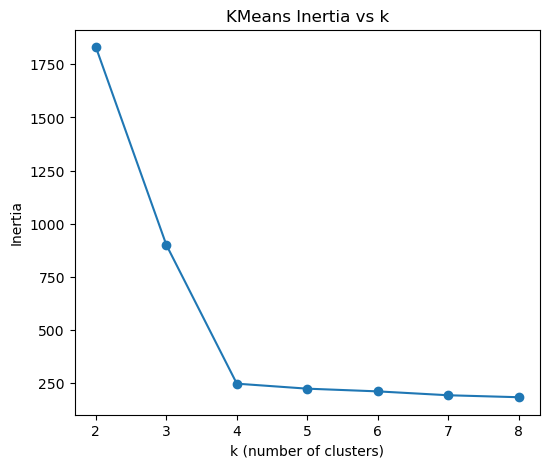

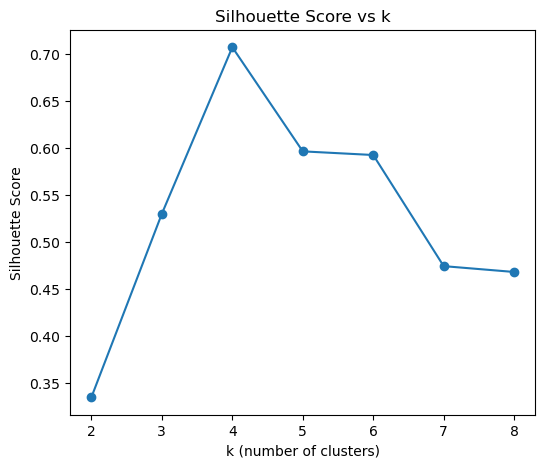

In [13]:
# TODO A.3
# 1) Loop over k values (e.g., 2..8) and fit KMeans.
# 2) Store inertia and silhouette for each k.
# 3) Make two line plots: inertia vs k, silhouette vs k.

inertia_values = []
silhouette_values = []

# ✅ 1) Loop over k values (2..8) and fit KMeans
for k in range(2, 8 + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X1_scaled)

    # ✅ 2) Store inertia and silhouette
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X1_scaled, kmeans.labels_))

# ✅ 3) Line plot — inertia vs k
plt.figure()
plt.plot(range(2, 9), inertia_values, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("KMeans Inertia vs k")
plt.show()

# ✅ 3) Line plot — silhouette vs k
plt.figure()
plt.plot(range(2, 9), silhouette_values, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

#### A.3 — Your Choice of k
Write 2–3 sentences explaining which **k** you chose based on the elbow and
silhouette plots.

_TODO: briefly justify your chosen k here._

### A.4 — Final K-Means Model & Cluster Quality
Using your chosen `k` from A.3:

1. Fit a final `KMeans` model on `X1_scaled`.
2. Store labels in `df1['kmeans_label']`.
3. Compute and print:
   - Silhouette score
   - Davies–Bouldin index
   - Calinski–Harabasz index
4. Make a **PCA 2D scatter plot** coloured by `kmeans_label`.

Silhouette Score: 0.7072
Davies–Bouldin Index: 0.3850
Calinski–Harabasz Index: 1509.3752


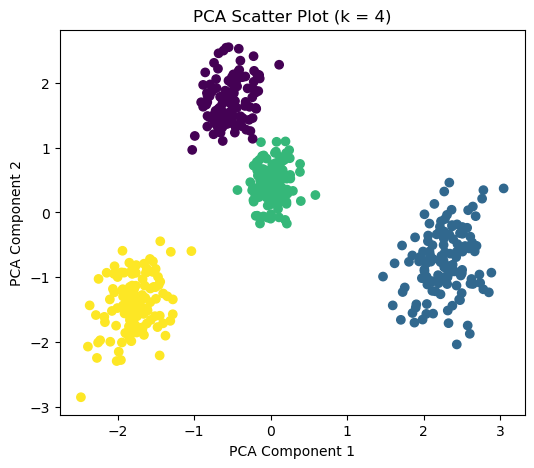

In [17]:
# TODO A.4
# 1) Fit KMeans with your chosen k and add labels to df1.
# 2) Compute silhouette, DB index, and CH index.
# 3) Run PCA(n_components=2) on X1_scaled and make a scatter plot
#    coloured by kmeans_label.

# ✅ 1) Fit KMeans with your chosen k and add labels to df1
best_k = 4
k = best_k   # <-- replace best_k with the k you selected earlier (e.g., 3 or 4)

kmeans = KMeans(n_clusters=k, random_state=42)
df1["kmeans_label"] = kmeans.fit_predict(X1_scaled)

# ✅ 2) Compute clustering metrics
sil = silhouette_score(X1_scaled, df1["kmeans_label"])
db  = davies_bouldin_score(X1_scaled, df1["kmeans_label"])
ch  = calinski_harabasz_score(X1_scaled, df1["kmeans_label"])

print(f"Silhouette Score: {sil:.4f}")
print(f"Davies–Bouldin Index: {db:.4f}")
print(f"Calinski–Harabasz Index: {ch:.4f}")

# ✅ 3) PCA → Scatter plot of clusters in 2D
pca = PCA(n_components=2)
X1_pca = pca.fit_transform(X1_scaled)

plt.figure()
plt.scatter(X1_pca[:, 0], X1_pca[:, 1], c=df1["kmeans_label"])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"PCA Scatter Plot (k = {k})")
plt.show()

### A.5 — Agglomerative (Hierarchical) Clustering
Now apply **AgglomerativeClustering** with `linkage='ward'`:

1. Use the **same number of clusters** as your final K-Means.
2. Fit on `X1_scaled` and store labels as `df1['agg_label']`.
3. Compute silhouette, Davies–Bouldin, and Calinski–Harabasz indices.
4. Make a PCA 2D scatter plot coloured by `agg_label`.
5. Briefly compare K-Means vs Agglomerative (which looks better and why?).

Silhouette Score: 0.7072
Davies–Bouldin Index: 0.3850
Calinski–Harabasz Index: 1509.3752


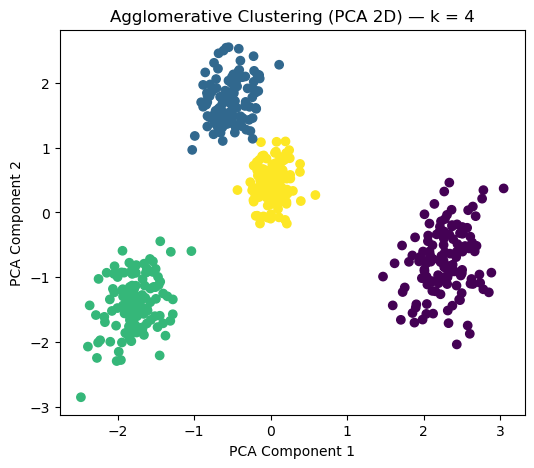

In [19]:
# TODO A.5
# 1) Fit AgglomerativeClustering with the same number of clusters.
# 2) Save labels and compute the three metrics.
# 3) Plot PCA(2D) projection coloured by agg_label.

# ✅ 1) Fit AgglomerativeClustering with the same number of clusters
k = best_k   # <-- same k you used for KMeans (e.g., 3 or 4)

agg = AgglomerativeClustering(n_clusters=k)
df1["agg_label"] = agg.fit_predict(X1_scaled)

# ✅ 2) Compute clustering metrics
sil = silhouette_score(X1_scaled, df1["agg_label"])
db  = davies_bouldin_score(X1_scaled, df1["agg_label"])
ch  = calinski_harabasz_score(X1_scaled, df1["agg_label"])

print(f"Silhouette Score: {sil:.4f}")
print(f"Davies–Bouldin Index: {db:.4f}")
print(f"Calinski–Harabasz Index: {ch:.4f}")

# ✅ 3) PCA(2D) projection coloured by agg_label
pca = PCA(n_components=2)
X1_pca = pca.fit_transform(X1_scaled)

plt.figure()
plt.scatter(X1_pca[:, 0], X1_pca[:, 1], c=df1["agg_label"])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"Agglomerative Clustering (PCA 2D) — k = {k}")
plt.show()

#### A.5 — Short Comparison
_TODO: in 2–3 bullet points, compare K-Means vs Agglomerative on Dataset 1._

---
## Part B — Dataset 2: Two Moons (Good for DBSCAN)

Now we use a classic **non-convex** dataset (two interleaving half-moons).
This is the situation where **DBSCAN** can shine and K-Means may struggle.

In [21]:
# DO NOT MODIFY THIS CELL
# Dataset 2: 2D non-convex "two moons" dataset
X2, y2_true = make_moons(n_samples=400, noise=0.08, random_state=42)

df2 = pd.DataFrame(X2, columns=['x1', 'x2'])
df2['true_label'] = y2_true
df2.head()

,x1,x2,true_label
0,-0.033226,0.420541,1
1,0.693183,-0.411493,1
2,0.836026,0.532761,0
3,0.145537,0.283647,1
4,0.093859,0.955842,0


### B.1 — Visualize the Two Moons
1. Scatter plot `x1` vs `x2` (no colour).
2. Scatter plot coloured by `true_label` to see the underlying structure.

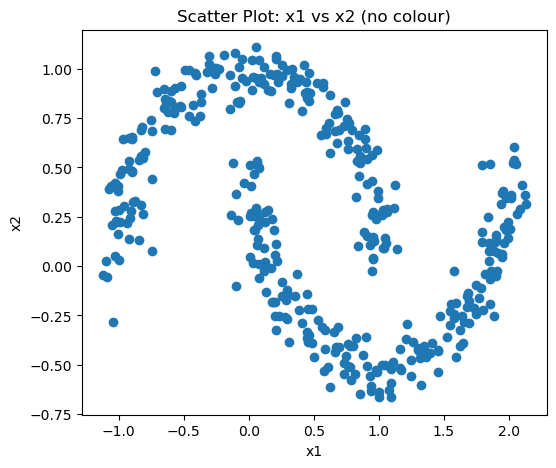

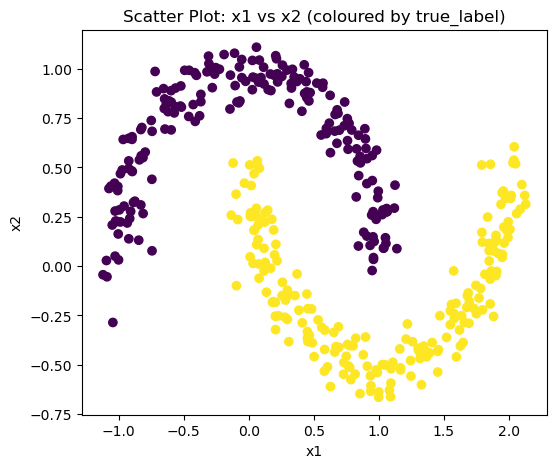

In [25]:
# TODO B.1
# 1) Scatter without colours.
# 2) Scatter coloured by true_label.

# Generate dataset
X2, y2_true = make_moons(n_samples=400, noise=0.08, random_state=42)

df2 = pd.DataFrame(X2, columns=['x1', 'x2'])
df2['true_label'] = y2_true

# ✅ 1) Scatter without colours
plt.figure()
plt.scatter(df2["x1"], df2["x2"])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Scatter Plot: x1 vs x2 (no colour)")
plt.show()

# ✅ 2) Scatter coloured by true_label
plt.figure()
plt.scatter(df2["x1"], df2["x2"], c=df2["true_label"])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Scatter Plot: x1 vs x2 (coloured by true_label)")
plt.show()

### B.2 — K-Means on the Moons
1. Standardize the two features and store as `X2_scaled`.
2. Run `KMeans(n_clusters=2, random_state=42, n_init=10)` on `X2_scaled`.
3. Store labels in `df2['kmeans_label']`.
4. Compute silhouette, Davies–Bouldin, and Calinski–Harabasz indices.
5. Make a scatter plot of `x1` vs `x2` coloured by `kmeans_label`.
6. Briefly comment: does K-Means capture the true moon shapes?

Silhouette Score: 0.4906
Davies–Bouldin Index: 0.8192
Calinski–Harabasz Index: 537.8876


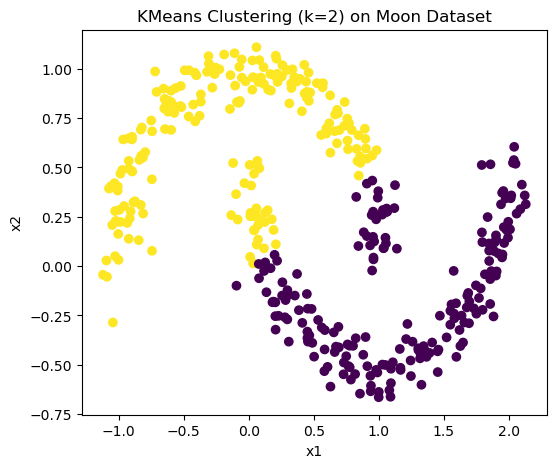

In [27]:
# TODO B.2
# 1) Standardize X2 and run KMeans with k=2.
# 2) Save labels and compute the three metrics.
# 3) Plot x1 vs x2 coloured by kmeans_label.

# ✅ 1) Standardize X2 and run KMeans with k=2
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(df2[['x1', 'x2']])

kmeans = KMeans(n_clusters=2, random_state=42)
df2["kmeans_label"] = kmeans.fit_predict(X2_scaled)

# ✅ 2) Compute metrics
sil = silhouette_score(X2_scaled, df2["kmeans_label"])
db  = davies_bouldin_score(X2_scaled, df2["kmeans_label"])
ch  = calinski_harabasz_score(X2_scaled, df2["kmeans_label"])

print(f"Silhouette Score: {sil:.4f}")
print(f"Davies–Bouldin Index: {db:.4f}")
print(f"Calinski–Harabasz Index: {ch:.4f}")

# ✅ 3) Scatter plot (x1 vs x2) coloured by kmeans_label
plt.figure()
plt.scatter(df2["x1"], df2["x2"], c=df2["kmeans_label"])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("KMeans Clustering (k=2) on Moon Dataset")
plt.show()

### B.3 — DBSCAN on the Moons
1. Choose initial values for `eps` and `min_samples` (e.g., eps=0.3, min_samples=5).
2. Fit `DBSCAN` on `X2_scaled` and store labels in `df2['dbscan_label']`.
3. Count how many points are labeled as **noise** (`label == -1`).
4. Compute silhouette score **only on non-noise points** (if at least 2 clusters).
5. Compute Davies–Bouldin and Calinski–Harabasz for non-noise points as well.
6. Make a scatter plot coloured by `dbscan_label` (treat noise as a separate colour/marker).

Number of noise points: 0
Silhouette Score (non-noise): 0.374
Calinski-Harabasz Score (non-noise): 327.360


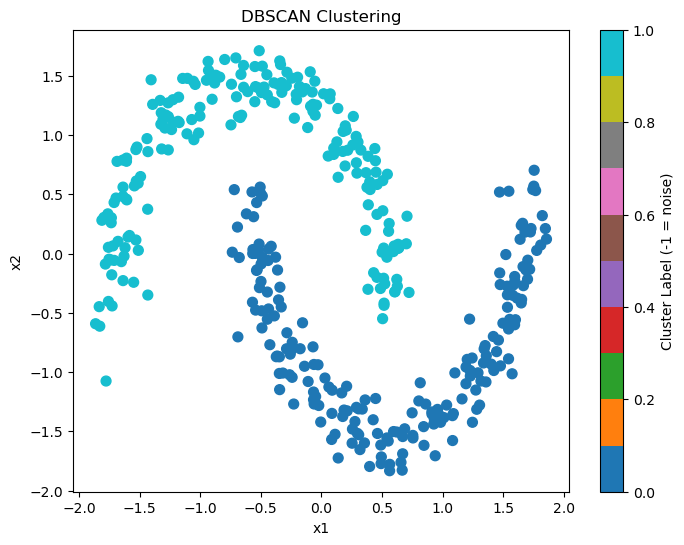

In [29]:
# TODO B.3
# 1) Fit DBSCAN on X2_scaled.
# 2) Count noise points and compute metrics on non-noise points (if valid).
# 3) Scatter x1 vs x2 coloured by dbscan_label (noise included).

# Assume X2_scaled is your scaled dataset (2D: x1, x2)
# 1) Fit DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # adjust eps/min_samples as needed
dbscan_labels = dbscan.fit_predict(X2_scaled)

# 2) Count noise points and compute metrics on non-noise points
noise_points = np.sum(dbscan_labels == -1)
print(f"Number of noise points: {noise_points}")

# Only consider non-noise points for metrics
mask = dbscan_labels != -1
if len(np.unique(dbscan_labels[mask])) > 1:  # silhouette requires >1 cluster
    sil_score = silhouette_score(X2_scaled[mask], dbscan_labels[mask])
    ch_score = calinski_harabasz_score(X2_scaled[mask], dbscan_labels[mask])
    print(f"Silhouette Score (non-noise): {sil_score:.3f}")
    print(f"Calinski-Harabasz Score (non-noise): {ch_score:.3f}")
else:
    print("Not enough clusters to compute metrics.")

# 3) Scatter plot x1 vs x2 coloured by DBSCAN labels (noise included)
plt.figure(figsize=(8,6))
plt.scatter(X2_scaled[:, 0], X2_scaled[:, 1], c=dbscan_labels, cmap='tab10', s=50)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('DBSCAN Clustering')
plt.colorbar(label='Cluster Label (-1 = noise)')
plt.show()

### B.4 — Compare K-Means vs DBSCAN on Dataset 2
In 3–5 bullet points, compare the two algorithms on the **two moons**:
- Which one matches the `true_label` structure more closely?
- How do the internal metrics compare?
- How sensitive is DBSCAN to your choice of `eps` and `min_samples`?

_TODO: add your comparison notes here._

---
## Part C — Overall Reflection
In 3–6 bullet points, summarise what you learned from **both datasets**:
- When does K-Means work well vs poorly?
- When is DBSCAN more appropriate?
- How useful were the internal metrics in guiding your choices?
- Did PCA help interpret the clusters in Dataset 1?

_You can answer in the space below or in a separate document, depending on
your instructor’s instructions._